In [5]:
!pip install python-aiml wikipedia pandas numpy scikit-learn nltk matplotlib seaborn tensorflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 47.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
All dependencies installed.


In [6]:
# Upload ALL four files at once:
#   mybot-basic.xml | ferrari_qa.csv | ferrari_kb.txt | ferrari_cnn_model.h5

from google.colab import files
import os

uploaded = files.upload()
print("\nFiles uploaded:")
for fname in uploaded:
    print(f"  {fname}  ({os.path.getsize(fname):,} bytes)")

Saving ferrari_cnn_model.h5 to ferrari_cnn_model.h5
Saving ferrari_qa.csv to ferrari_qa.csv
Saving ferrari_kb.txt to ferrari_kb.txt
Saving mybot-basic.xml to mybot-basic.xml

Files uploaded:
  ferrari_cnn_model.h5  (31,186,480 bytes)
  ferrari_qa.csv  (5,570 bytes)
  ferrari_kb.txt  (2,055 bytes)
  mybot-basic.xml  (12,967 bytes)


In [7]:
import nltk
nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

NLTK data ready.


In [14]:
import os, io, re, requests
import aiml
import wikipedia
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.sem import Expression
from nltk.inference import ResolutionProver
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image

#Class names
CLASS_NAMES = [
    '12cilindri', '296', '355', '512', '812',
    'concepts', 'custom', 'endurance_racing',
    'f80', 'formula_1', 'novitec', 'roma', 'sf90'
]

#Reference images
CLASS_REFERENCE_IMAGES = {
    '12cilindri':       'https://upload.wikimedia.org/wikipedia/commons/d/dd/2025_Ferrari_12Cilindri_in_Rosso_Imola%2C_front_left.jpg',
    '296':              'https://upload.wikimedia.org/wikipedia/commons/4/46/2022_Ferrari_296_%28cropped%29.jpg',
    '355':              'https://upload.wikimedia.org/wikipedia/commons/b/b9/Ferrari_F355_Berlinetta_1X7A7333.jpg',
    '512':              'https://upload.wikimedia.org/wikipedia/commons/1/1c/1970_Ferrari_512_S.jpg',
    '812':              'https://upload.wikimedia.org/wikipedia/commons/thumb/2/24/Ferrari_812_Superfast_IMG_8829.jpg/1280px-Ferrari_812_Superfast_IMG_8829.jpg',
    'concepts':         'https://car-images.bauersecure.com/wp-images/158126/ferrari_vision_gt_18.jpg',
    'custom':           'https://upload.wikimedia.org/wikipedia/commons/1/15/Ferrari_SP38.jpg',
    'endurance_racing': 'https://upload.wikimedia.org/wikipedia/commons/9/91/2024_24_Hours_of_Le_Mans_%2854093434907%29.jpg',
    'f80':              'https://upload.wikimedia.org/wikipedia/commons/7/7f/FerrariF80_%28resized%29_%28cropped%29.jpg',
    'formula_1':        'https://upload.wikimedia.org/wikipedia/commons/b/b8/2025_Japan_GP_-_Ferrari_-_Lewis_Hamilton_-_FP1.jpg',
    'novitec':          'https://s1.cdn.autoevolution.com/images/news/gallery/new-novitec-ferrari-f8-n-largo-is-a-limited-edition-space-ship-already-sold-out_1.jpg',
    'roma':             'https://res.cloudinary.com/unix-center/image/upload/c_limit,dpr_3.0,f_auto,fl_progressive,g_center,h_240,q_auto:good,w_385/doytd8nw257vjtptpz8a.jpg',
    'sf90':             'https://www.topgear.com/sites/default/files/cars-car/image/2020/07/dsc09285.jpg',
}

def fetch_image_from_url(url):
    """Download an image from a URL and return as PIL Image, or None."""
    try:
        r = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
        r.raise_for_status()
        return Image.open(io.BytesIO(r.content)).convert('RGB')
    except Exception:
        return None

#AIML
kern = aiml.Kernel()
kern.setTextEncoding(None)
kern.bootstrap(learnFiles="mybot-basic.xml")
print("AIML loaded.")

#Similarity Q/A
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = nltk.word_tokenize(text.lower())
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

qa_df         = pd.read_csv("ferrari_qa.csv")
questions     = qa_df['question'].tolist()
answers       = qa_df['answer'].tolist()
lemmatised_qs = [lemmatize_text(q) for q in questions]
vectorizer    = TfidfVectorizer()
tfidf_matrix  = vectorizer.fit_transform(lemmatised_qs)

def get_similarity_answer(user_input, threshold=0.15):
    lem  = lemmatize_text(user_input)
    vec  = vectorizer.transform([lem])
    sims = cosine_similarity(vec, tfidf_matrix)[0]
    best = int(np.argmax(sims))
    return answers[best] if sims[best] >= threshold else None

print("Similarity Q/A loaded.")

#Knowledge Base
read_expr = Expression.fromstring

def load_kb(filepath="ferrari_kb.txt"):
    kb = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            try:
                kb.append(read_expr(line))
            except Exception as e:
                print(f"  [KB WARNING] {line}: {e}")
    return kb

def check_contradiction(kb, new_expr):
    try:
        return ResolutionProver().prove(read_expr(f'(-{new_expr})'), kb, verbose=False)
    except:
        return False

def kb_query(kb, query_expr):
    try:
        if ResolutionProver().prove(query_expr, kb, verbose=False):
            return "Correct"
        if ResolutionProver().prove(read_expr(f'(-{query_expr})'), kb, verbose=False):
            return "Incorrect"
    except:
        pass
    return "I don't know"

kb = load_kb("ferrari_kb.txt")
print(f"KB loaded — {len(kb)} expressions.")

def handle_i_know(subject, predicate):
    expr_str = f"{predicate.replace(' ','_').capitalize()}({subject.replace(' ','_').capitalize()})"
    try:
        new_expr = read_expr(expr_str)
    except:
        return "I couldn't parse that. Try a simpler statement."
    if check_contradiction(kb, new_expr):
        return f"That contradicts something I already know. I can't accept that {subject} is {predicate}."
    if new_expr in kb:
        return f"I already know that {subject} is {predicate}."
    kb.append(new_expr)
    return f"OK, I will remember that {subject} is {predicate}."

def handle_check_that(subject, predicate):
    expr_str = f"{predicate.replace(' ','_').capitalize()}({subject.replace(' ','_').capitalize()})"
    try:
        return kb_query(kb, read_expr(expr_str))
    except:
        return "I couldn't parse that query."

#CNN model
cnn_model = None
try:
    if os.path.exists("ferrari_cnn_model.h5"):
        cnn_model = load_model("ferrari_cnn_model.h5")
        print(f"CNN model loaded — {cnn_model.output_shape[-1]} classes.")
    else:
        print("[INFO] ferrari_cnn_model.h5 not found — image classification disabled.")
except Exception as e:
    print(f"[INFO] Could not load CNN: {e}")

#Classification with 3-panel display
def classify_and_show(pil_img):
    """
    Run CNN on pil_img and display:
      Left   — the input image
      Middle — confidence bar chart for all 13 classes
      Right  — reference photo of the predicted class
    """
    if cnn_model is None:
        print("Image classification not available — model not loaded.")
        return

    # Run prediction
    img_r = pil_img.convert('RGB').resize((224, 224))
    arr   = np.expand_dims(keras_image.img_to_array(img_r) / 255.0, axis=0)
    preds = cnn_model.predict(arr, verbose=0)
    confs = [float(p) * 100 for p in preds[0]]
    best  = int(np.argmax(preds[0]))
    labels = [c.replace('_', ' ').title() for c in CLASS_NAMES]
    predicted_class = CLASS_NAMES[best]
    predicted_label = labels[best]
    best_conf       = confs[best]

    # Fetch reference image for predicted class
    ref_url = CLASS_REFERENCE_IMAGES.get(predicted_class)
    ref_img = fetch_image_from_url(ref_url) if ref_url else None

    # Build figure
    n_panels = 3 if ref_img else 2
    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, n_panels, figure=fig,
                            width_ratios=[1, 1.4, 1] if ref_img else [1, 1.4])

    # Panel 1 — input image
    ax_input = fig.add_subplot(gs[0])
    ax_input.imshow(pil_img)
    ax_input.axis('off')
    ax_input.set_title("Your Image", fontsize=12, fontweight='bold')

    # Panel 2 — confidence bar chart
    ax_bar = fig.add_subplot(gs[1])
    colours = ['#c0392b' if i == best else '#bdc3c7' for i in range(len(CLASS_NAMES))]
    bars = ax_bar.barh(labels, confs, color=colours)
    ax_bar.set_xlim(0, 105)
    ax_bar.set_xlabel("Confidence (%)")
    ax_bar.set_title("CNN Classification Confidence", fontsize=12, fontweight='bold')
    for bar, conf in zip(bars, confs):
        ax_bar.text(min(conf + 1, 101), bar.get_y() + bar.get_height() / 2,
                    f"{conf:.1f}%", va='center', fontsize=8)

    # Panel 3 — reference image of predicted class
    if ref_img:
        ax_ref = fig.add_subplot(gs[2])
        ax_ref.imshow(ref_img)
        ax_ref.axis('off')
        ax_ref.set_title(f"Ferrari {predicted_label}\n(Reference)", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Text summary
    print(f"\n🏎️  Prediction : Ferrari {predicted_label}")
    print(f"   Confidence : {best_conf:.1f}%")
    if best_conf < 50:
        print("   ⚠️  Low confidence — the model is uncertain between multiple classes.")
        print("      Check the bar chart to see all scores.")
    if ref_img is None:
        print(f"   (Reference image not available for '{predicted_class}')")

# URL pattern
URL_IMAGE_PATTERN = re.compile(
    r'https?://\S+\.(?:jpg|jpeg|png|bmp|webp)(\?\S*)?',
    re.IGNORECASE
)

IKNOW_PATTERN = re.compile(r"i know that (.+?) is (.+)", re.IGNORECASE)
CHECK_PATTERN = re.compile(r"check that (.+?) is (.+)",  re.IGNORECASE)

print("Run Cell 5 to chat, Cell 6 to upload an image, Cell 7 to classify by URL.")

Loading mybot-basic.xml...done (0.00 seconds)
Kernel bootstrap completed in 0.00 seconds
AIML loaded.
Similarity Q/A loaded.
KB loaded — 52 expressions.


CNN model loaded — 13 classes.

✅ All components ready.
Run Cell 5 to chat, Cell 6 to upload an image, Cell 7 to classify by URL.


  FerrariBot — Your Ferrari Expert
Ask me about Ferrari models, specs, history, F1.
  'I know that SF90 is a Hybrid'
  'Check that F80 is a Hypercar'
  To classify an image → run Cell 6 or Cell 7
Type 'bye' or 'exit' to stop.

> https://upload.wikimedia.org/wikipedia/commons/thumb/e/e0/FIA_F1_Austria_2024_Nr._16_Leclerc.jpg/330px-FIA_F1_Austria_2024_Nr._16_Leclerc.jpg


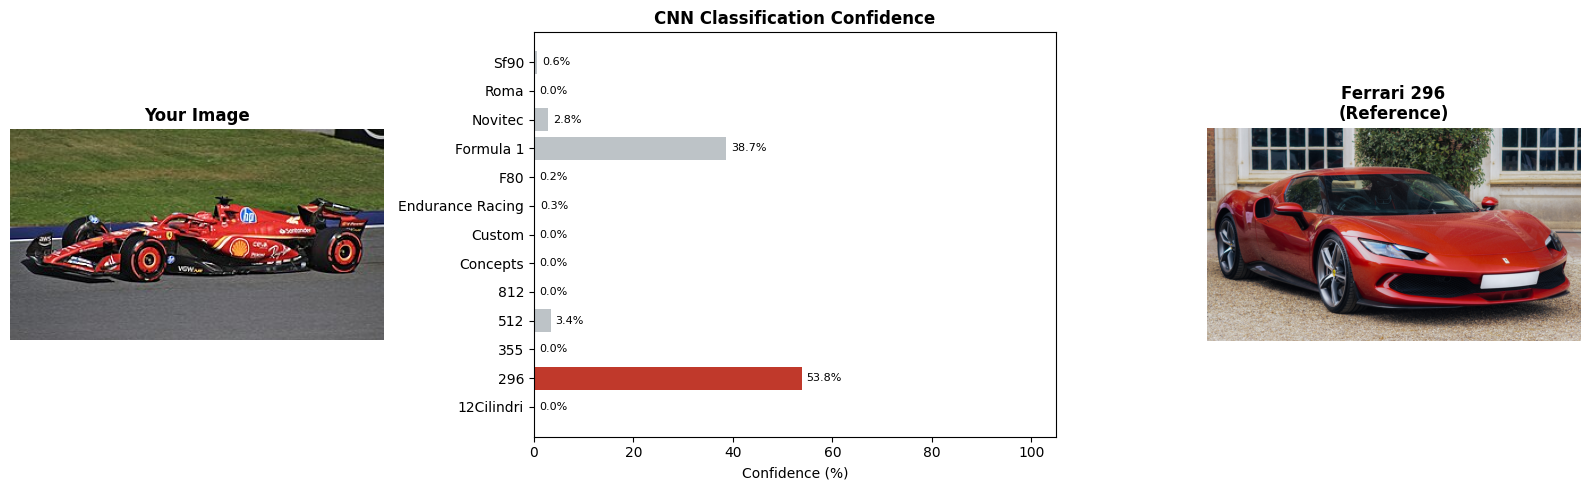


🏎️  Prediction : Ferrari 296
   Confidence : 53.8%
> https://www.amalgamcollection.com/cdn/shop/products/DSCF0611WIDEEDIT_2000x850_crop_center.jpg?v=1667414099


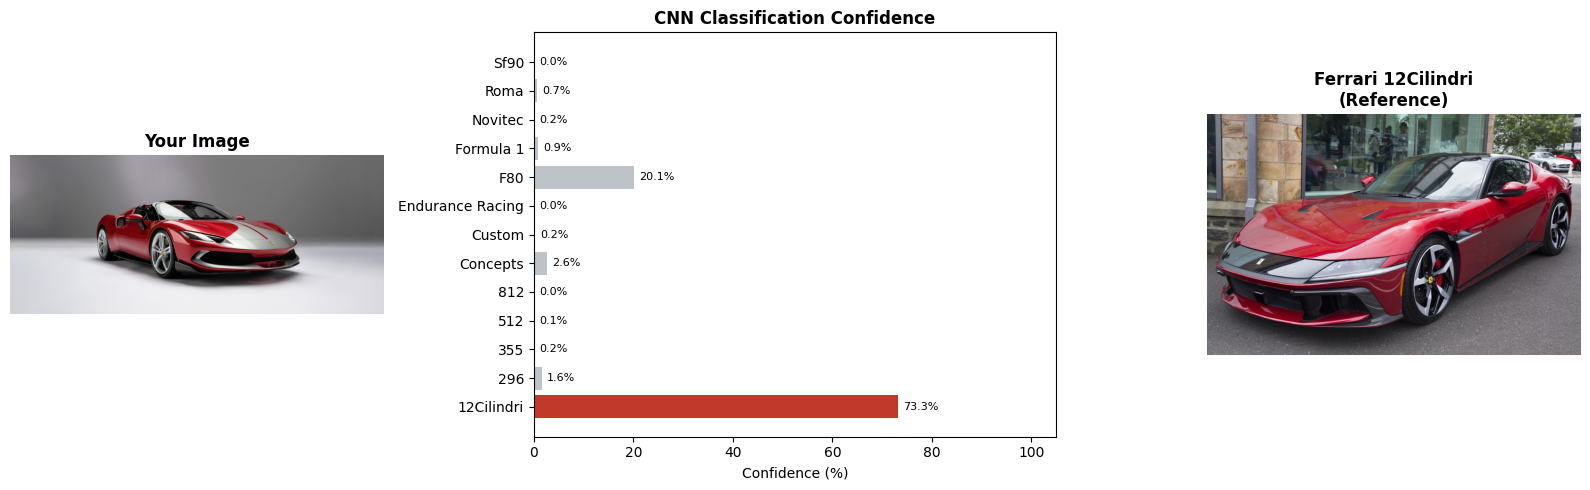


🏎️  Prediction : Ferrari 12Cilindri
   Confidence : 73.3%
> https://static0.hotcarsimages.com/wordpress/wp-content/uploads/wm/2023/02/184cd58e-7c10-4c3e-92b2-f94d8c27f37d.jpeg?w=1600&h=900&fit=crop


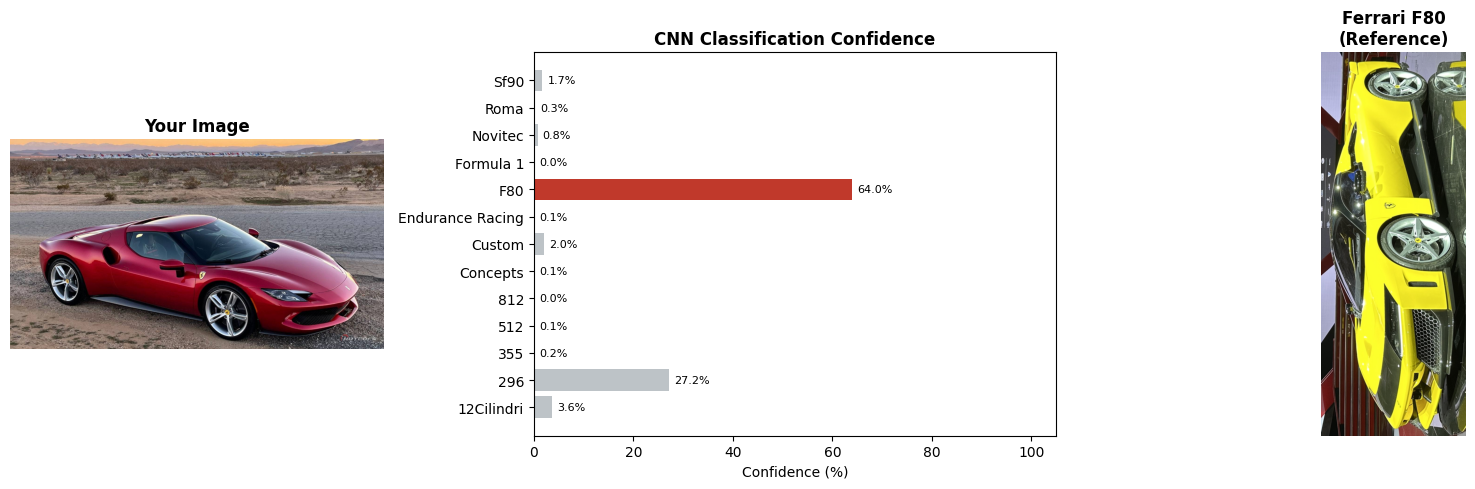


🏎️  Prediction : Ferrari F80
   Confidence : 64.0%
> https://static.wikia.nocookie.net/forzamotorsport/images/e/eb/FH5_Ferrari_296_GTB_2022_Large.png/revision/latest?cb=20230822225815


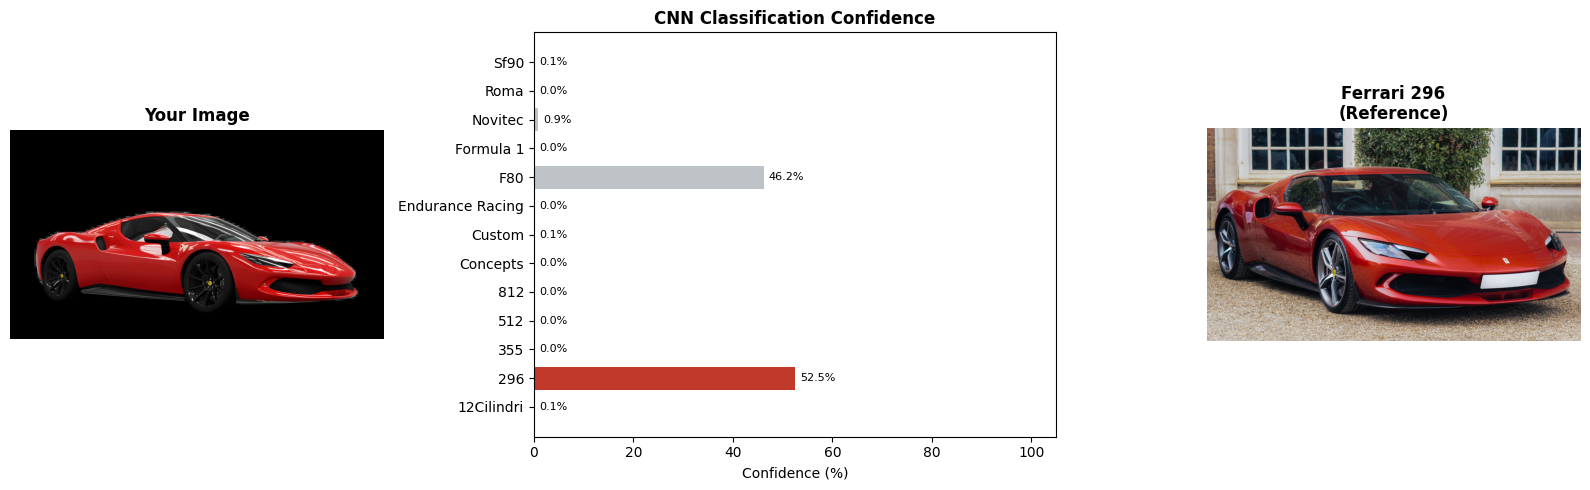


🏎️  Prediction : Ferrari 296
   Confidence : 52.5%
> https://www.amalgamcollection.com/cdn/shop/articles/01_591278ab-6c68-4a0b-afeb-19bc9415575e_1024x1024.jpg?v=1729505170


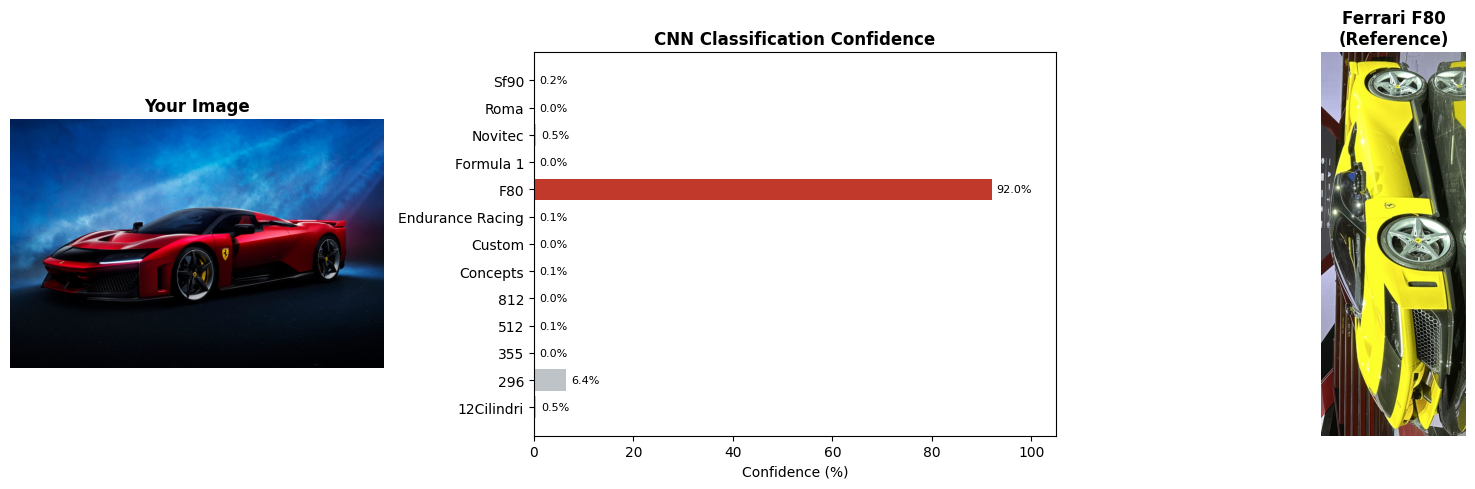


🏎️  Prediction : Ferrari F80
   Confidence : 92.0%
> https://cdn.ferrari.com/cms/network/media/img/resize/662cee0da44e370010b5476f-ferrari-12cilindri-share-intro?width=1080
The 12Cilindri uses a naturally aspirated 6.5 litre V12 engine producing 830 hp at 9500 rpm. It is essentially the same architecture as the 812 Competizione engine but refined further. Ferrari chose to keep it naturally aspirated rather than adding turbochargers or hybridisation
> https://exoticcars.ae/uploads/blog-images/229/img.png


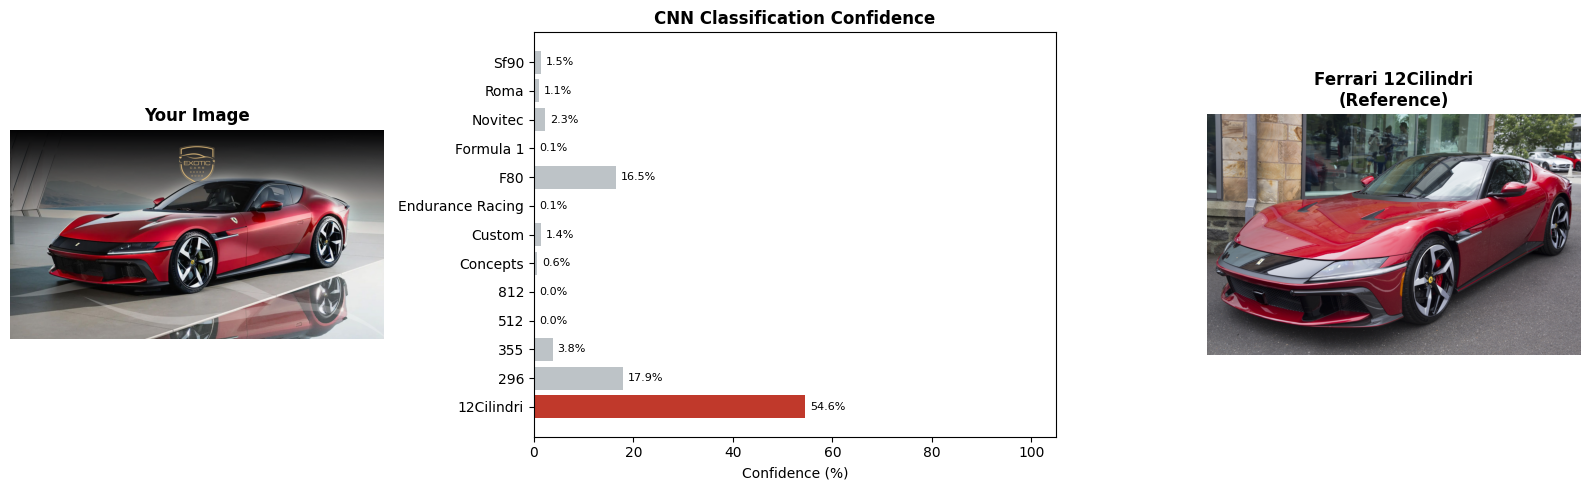


🏎️  Prediction : Ferrari 12Cilindri
   Confidence : 54.6%
> https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRWMo4z0515XOQJ-kYKBs_qjL4sNcsUyuToRQ&s
I'm not sure about that one. Try asking about a specific Ferrari model, specs, or history.
> https://www.topgear.com/sites/default/files/images/news-article/2025/10/7c399d2c709b9d903552bb66905e7996/MFA04017.jpg


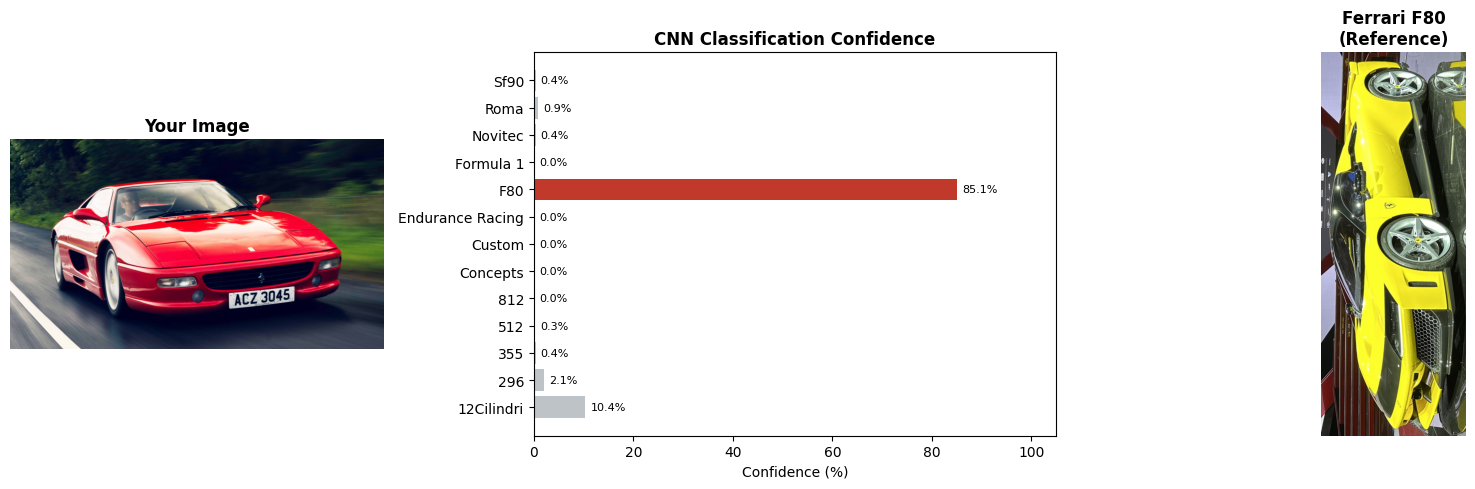


🏎️  Prediction : Ferrari F80
   Confidence : 85.1%
> hello
Hey! Welcome to FerrariBot. Ask me anything about Ferrari — models, specs, history, F1, you name it.
> hi
Hey! Welcome to FerrariBot. Ask me anything about Ferrari — models, specs, history, F1, you name it.
> how are you
Running at full throttle, thanks. What Ferrari question can I answer for you?
> I know that the SF90 is a Hybrid
I already know that the SF90 is a Hybrid.
> Check if the SF90 is a Hybrid
The SF90 Stradale is Ferrari's first series-production plug-in hybrid. It combines a twin-turbo 4.0L V8 with three electric motors for a combined 986 hp output. Two electric motors sit on the front axle giving it four-wheel drive — a first for a mid-engined Ferrari road car. It can also run in full electric mode for short distances. The XX Stradale variant released in 2024 pushed the figure to 1016 hp.
Bye!


In [25]:
#Cell 5: Chat
print("=" * 52)
print("  FerrariBot — Your Ferrari Expert")
print("=" * 52)
print("Ask me about Ferrari models, specs, history, F1.")
print("  'I know that SF90 is a Hybrid'")
print("  'Check that F80 is a Hypercar'")
print("  To classify an image → run Cell 6 or Cell 7")
print("Type 'bye' or 'exit' to stop.\n")

while True:
    try:
        user_input = input("> ").strip()
    except (KeyboardInterrupt, EOFError):
        print("Bye!")
        break

    if not user_input:
        continue

    # Catch Google search URLs
    if 'google.com/imgres' in user_input or 'google.com/search' in user_input:
        print("That's a Google search URL — it won't work directly.")
        print("Right-click the image → 'Open image in new tab' → copy that URL.")
        print("Or run Cell 6 to upload an image file from your computer.")
        continue

    # Direct image URL in chat
    url_match = URL_IMAGE_PATTERN.search(user_input)
    if url_match:
        img = fetch_image_from_url(url_match.group(0))
        if img:
            classify_and_show(img)
        else:
            print("Couldn't fetch that image. Try Cell 6 to upload it directly.")
        continue

    # FOL
    m = IKNOW_PATTERN.match(user_input)
    if m:
        print(handle_i_know(m.group(1).strip(), m.group(2).strip()))
        continue

    m = CHECK_PATTERN.match(user_input)
    if m:
        print(handle_check_that(m.group(1).strip(), m.group(2).strip()))
        continue

    # AIML
    answer = kern.respond(user_input)
    if answer and answer[0] == '#':
        params = answer[1:].split('$')
        cmd    = int(params[0])
        if cmd == 0:
            print(params[1])
            break
        elif cmd == 1:
            try:
                print(wikipedia.summary(params[1], sentences=3, auto_suggest=True))
            except:
                print("I couldn't find anything on that. Try being more specific.")
        elif cmd == 99:
            sim = get_similarity_answer(user_input)
            print(sim if sim else "I'm not sure about that one. Try asking about a specific Ferrari model, specs, or history.")
    else:
        print(answer)

Select an image file to classify:


Saving FIA_F1_Imola_2025_No._44_Hamilton_(4)_(cropped).jpg to FIA_F1_Imola_2025_No._44_Hamilton_(4)_(cropped) (1).jpg
Loaded: FIA_F1_Imola_2025_No._44_Hamilton_(4)_(cropped) (1).jpg


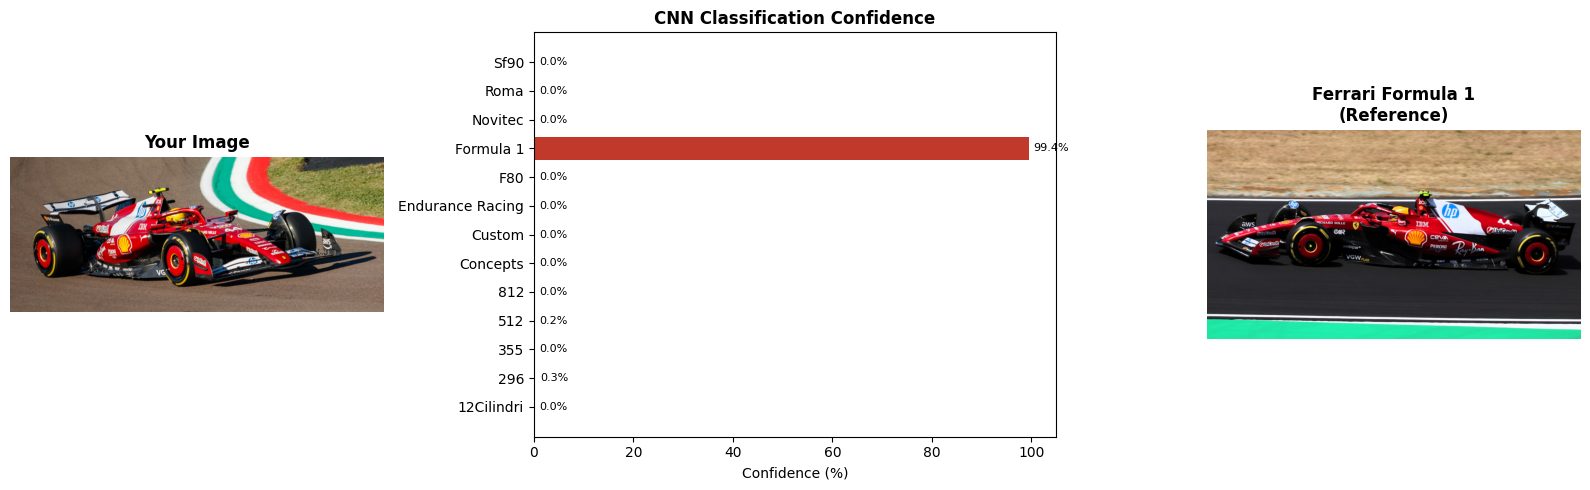


🏎️  Prediction : Ferrari Formula 1
   Confidence : 99.4%


In [24]:
from google.colab import files

print("Select an image file to classify:")
uploaded_img = files.upload()

if uploaded_img:
    fname = list(uploaded_img.keys())[0]
    img   = Image.open(io.BytesIO(uploaded_img[fname])).convert('RGB')
    print(f"Loaded: {fname}")
    classify_and_show(img)
else:
    print("No file selected.")

In [26]:
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Ferrari_SF90_Stradale_2020.jpg/1280px-Ferrari_SF90_Stradale_2020.jpg"

img = fetch_image_from_url(IMAGE_URL)
if img:
    classify_and_show(img)
else:
    print("Failed to fetch image.")
    print("Make sure the URL is a direct link to an image file, not a search or redirect page.")

Failed to fetch image.
Make sure the URL is a direct link to an image file, not a search or redirect page.
